# KL Divergence: Building Intuition from the Ground Up

**Goal**: Understand KL divergence not just as a formula, but as a natural consequence of thinking about information, prediction, and probability.

**Journey**: We'll build from simple ideas to complex ones:
1. **Information content** - Why rare events are "surprising"
2. **Entropy** - The average surprise in a distribution
3. **Cross-entropy** - What happens when we use the wrong distribution
4. **KL divergence** - The "extra" cost of being wrong

By the end, you'll see KL divergence everywhere in ML: VAEs, reinforcement learning, model training, and more.

## 1. Why Do We Need This?

Imagine you're training a generative model to produce realistic images. Your model outputs a probability distribution over pixels, but how do you measure if it's getting closer to the true distribution?

- **Not just difference in means** - Two distributions can have the same mean but very different shapes
- **Not just difference in variances** - They can have the same variance but different shapes
- **We need to compare entire distributions** - KL divergence does this

**Other scenarios:**
- **Reinforcement learning**: How different is my new policy from the old one? (Need to stay close for stability)
- **VAEs**: How different is the learned latent distribution from a standard normal? (Regularization)
- **Compression**: How many extra bits do I need if I use the wrong probability model?

Let's build the intuition to understand this powerful tool.

## 2. Setup

We'll import standard libraries for numerical computing and visualization, plus utilities from the shared library.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from scipy import stats

from aiml_notebooks import set_seed, get_device

%load_ext autoreload
%autoreload 2

Set random seed for reproducibility and configure the device.

In [2]:
set_seed(42)
device = get_device()
print(f"Using device: {device}")

Using MPS (Metal Performance Shaders) for GPU acceleration
Using device: mps


Configure matplotlib for better-looking plots.

In [3]:
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['lines.linewidth'] = 2

## 3. Foundation: Information Content (Surprisal)

### The Core Intuition

**Question**: If I tell you something happened, how much information did I give you?

**Answer**: It depends on how surprising the event was!

**Analogies:**
1. **Weather**: "It's sunny in Los Angeles" → Not surprising, low information. "It's snowing in Los Angeles" → Very surprising, high information!
2. **Headlines**: "Dog bites man" → Common, boring, low information. "Man bites dog" → Rare, newsworthy, high information!
3. **Coins**: "The coin landed heads" → 50% chance, moderate information. "The coin landed on its edge" → 0.01% chance, huge information!

**The pattern**: Rare events (low probability) carry more information than common events (high probability).

**Mathematical formulation**: Information content $I(x)$ should:
- Be inversely related to probability: lower $p(x)$ → higher $I(x)$
- Be positive: $I(x) \geq 0$
- Be additive for independent events: $I(x, y) = I(x) + I(y)$ if $x$ and $y$ are independent

The function that satisfies these properties is the **negative logarithm**:

$$I(x) = -\log_2 p(x)$$

(We use base 2 to measure in "bits" - think binary digits needed to encode the event)

### Why Logarithm?

Let's see why $-\log$ is the natural choice:

1. **Inverse relationship**: As $p$ increases, $-\log p$ decreases
2. **Additivity**: $-\log(p \cdot q) = -\log p + (-\log q)$ - perfect for independent events!
3. **Intuitive scale**: Goes from 0 (certain event, $p=1$) to infinity (impossible event, $p→0$)

Let's visualize this relationship.

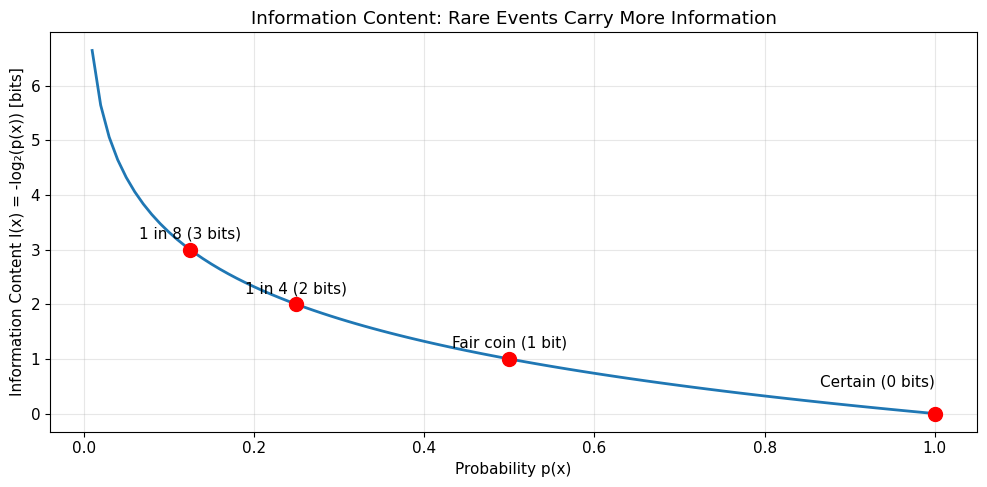

In [4]:
# Create a range of probabilities
probs = np.linspace(0.01, 1.0, 100)
information = -np.log2(probs)

plt.figure(figsize=(10, 5))
plt.plot(probs, information, linewidth=2)
plt.xlabel('Probability p(x)')
plt.ylabel('Information Content I(x) = -log₂(p(x)) [bits]')
plt.title('Information Content: Rare Events Carry More Information')
plt.grid(True, alpha=0.3)

# Annotate key points
plt.scatter([1.0, 0.5, 0.25, 0.125], 
           [-np.log2(1.0), -np.log2(0.5), -np.log2(0.25), -np.log2(0.125)],
           color='red', s=100, zorder=5)
plt.text(1.0, 0.5, 'Certain (0 bits)', ha='right')
plt.text(0.5, 1.2, 'Fair coin (1 bit)', ha='center')
plt.text(0.25, 2.2, '1 in 4 (2 bits)', ha='center')
plt.text(0.125, 3.2, '1 in 8 (3 bits)', ha='center')

plt.tight_layout()
plt.show()

**Interpretation**: 
- A certain event ($p=1$) gives 0 bits of information - you learned nothing!
- A fair coin flip ($p=0.5$) gives 1 bit - you need one binary question to distinguish it
- Rarer events give more bits - you need more binary questions to narrow down to them

### Concrete Examples

Let's compute information content for real scenarios.

In [5]:
def information_content(p):
    """Compute information content in bits"""
    return -np.log2(p)

# Weather examples
print("=== Weather in Los Angeles ===")
p_sunny = 0.7
p_snow = 0.001
print(f"'Sunny today': p={p_sunny:.3f} → I={information_content(p_sunny):.2f} bits")
print(f"'Snow today': p={p_snow:.3f} → I={information_content(p_snow):.2f} bits")
print(f"Snow is {information_content(p_snow) / information_content(p_sunny):.1f}x more informative!\n")

# Coin examples
print("=== Coin Flips ===")
p_heads = 0.5
p_edge = 0.0001
print(f"'Landed heads': p={p_heads:.3f} → I={information_content(p_heads):.2f} bits")
print(f"'Landed on edge': p={p_edge:.4f} → I={information_content(p_edge):.2f} bits")
print(f"Edge is {information_content(p_edge) / information_content(p_heads):.1f}x more informative!\n")

# Lottery
print("=== Lottery ===")
p_win = 1 / 292_201_338  # Powerball odds
print(f"'You won!': p={p_win:.2e} → I={information_content(p_win):.2f} bits")
print(f"That's like flipping {information_content(p_win):.0f} coins and getting all heads!")

=== Weather in Los Angeles ===
'Sunny today': p=0.700 → I=0.51 bits
'Snow today': p=0.001 → I=9.97 bits
Snow is 19.4x more informative!

=== Coin Flips ===
'Landed heads': p=0.500 → I=1.00 bits
'Landed on edge': p=0.0001 → I=13.29 bits
Edge is 13.3x more informative!

=== Lottery ===
'You won!': p=3.42e-09 → I=28.12 bits
That's like flipping 28 coins and getting all heads!


### Key Insight

**Information content measures surprise**: When something unlikely happens, we gain a lot of information. When something expected happens, we gain little.

This is the foundation of everything that follows. Keep this intuition in mind:
- **High probability** → Low surprise → Low information
- **Low probability** → High surprise → High information

## 4. Entropy: Average Information

### The Core Intuition

We now know how much information a single event carries. But what about an entire probability distribution? How "surprising" is it on average?

**Analogies:**
1. **Predictable vs Unpredictable**: 
   - A loaded die that always shows 6 → Very predictable, low average surprise
   - A fair die → Unpredictable, higher average surprise
2. **Language**:
   - English text → Some letters common (e, t, a), some rare (q, x, z) → Medium entropy
   - Random gibberish → All letters equally likely → Maximum entropy
   - Repeating "AAAA..." → One letter always → Zero entropy
3. **Weather**:
   - Death Valley (always sunny) → Low entropy, predictable
   - Seattle (rain, sun, clouds all possible) → Higher entropy, less predictable

**The pattern**: Entropy measures the average unpredictability or "disorder" in a distribution.

**Mathematical definition**: Entropy $H(P)$ is the expected information content:

$$H(P) = \mathbb{E}_{x \sim P}[I(x)] = -\sum_{x} p(x) \log_2 p(x)$$

We're taking each event's information, weighting by how often it occurs, and averaging.

### Why Is This Useful?

Entropy tells us:
- **Minimum bits needed to encode outcomes** - Can't compress below entropy without losing information
- **How unpredictable the system is** - Higher entropy = harder to predict
- **How "spread out" the probability mass is** - Uniform distribution has maximum entropy

Let's implement and visualize this.

In [6]:
def entropy(p):
    """Compute entropy in bits. p is a numpy array of probabilities."""
    # Filter out zero probabilities (0 * log(0) = 0 by convention)
    p_nonzero = p[p > 0]
    return -np.sum(p_nonzero * np.log2(p_nonzero))

# Example 1: Loaded die (always shows 6)
p_loaded = np.array([0, 0, 0, 0, 0, 1.0])
H_loaded = entropy(p_loaded)
print(f"Loaded die (always 6): H = {H_loaded:.3f} bits")
print("  → Perfectly predictable, zero surprise\n")

# Example 2: Fair die
p_fair = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])
H_fair = entropy(p_fair)
print(f"Fair die: H = {H_fair:.3f} bits")
print("  → Maximum unpredictability for 6 outcomes\n")

# Example 3: Slightly loaded die (favors 6)
p_slightly_loaded = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.5])
H_slightly_loaded = entropy(p_slightly_loaded)
print(f"Slightly loaded die: H = {H_slightly_loaded:.3f} bits")
print("  → Less unpredictable than fair, more than fully loaded\n")

# Maximum entropy for 6 outcomes
print(f"Maximum possible entropy with 6 outcomes: {np.log2(6):.3f} bits")
print("  → Achieved when all outcomes are equally likely")

Loaded die (always 6): H = -0.000 bits
  → Perfectly predictable, zero surprise

Fair die: H = 2.585 bits
  → Maximum unpredictability for 6 outcomes

Slightly loaded die: H = 2.161 bits
  → Less unpredictable than fair, more than fully loaded

Maximum possible entropy with 6 outcomes: 2.585 bits
  → Achieved when all outcomes are equally likely


**Observation**: 
- Entropy ranges from 0 (deterministic) to $\log_2(n)$ (uniform over $n$ outcomes)
- The fair die achieves maximum entropy
- Any bias reduces entropy

### Visualizing Entropy Across Different Distributions

Let's see how entropy changes as we vary the probability distribution.

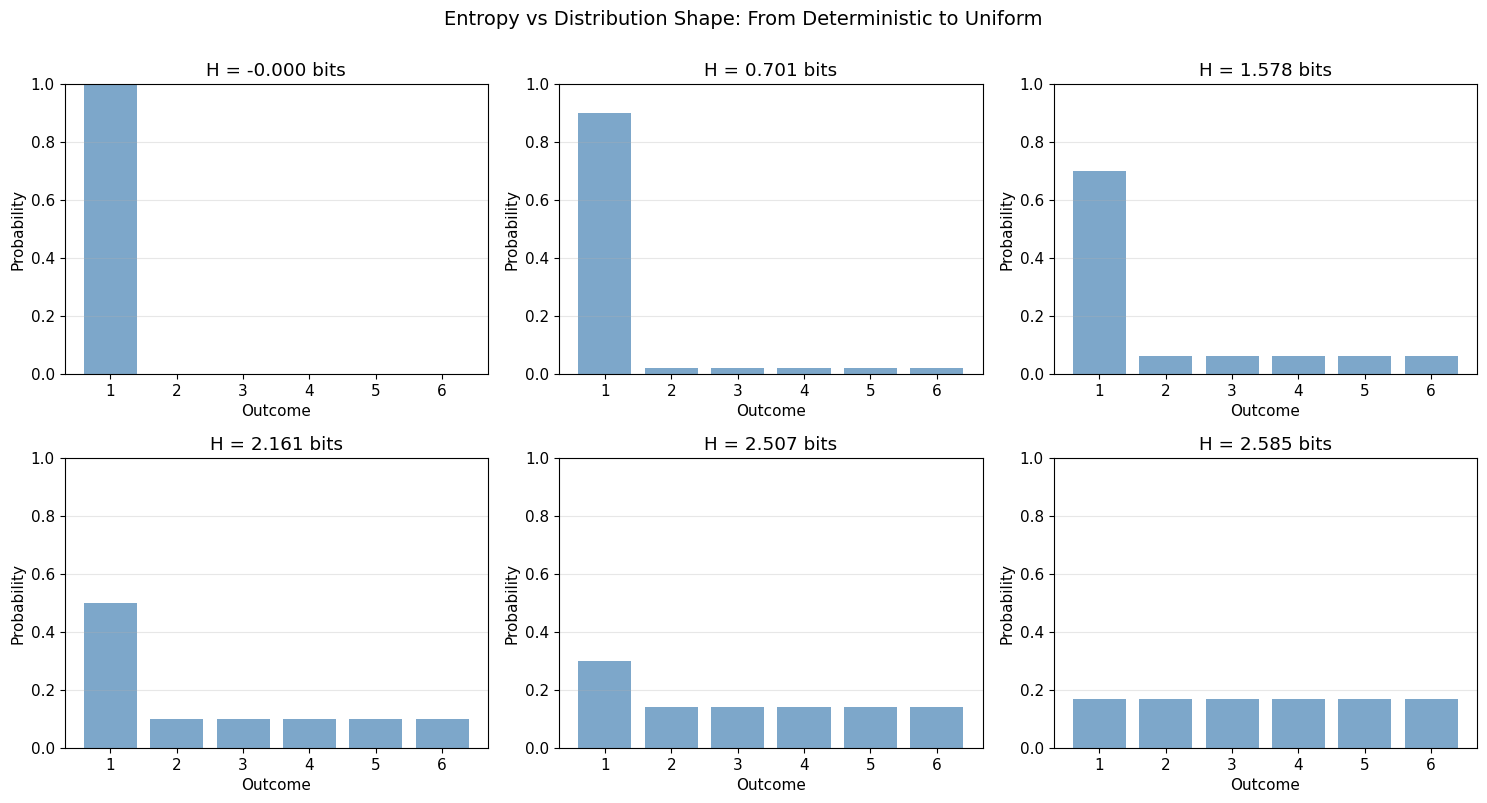

In [7]:
# Create a spectrum from deterministic to uniform
# p(outcome_1) varies from 0.5 to 1.0, rest is uniform
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

p_values = [1.0, 0.9, 0.7, 0.5, 0.3, 1/6]

for idx, p_first in enumerate(p_values):
    if p_first == 1/6:
        # Fair die
        p_dist = np.ones(6) / 6
    else:
        # First outcome has probability p_first, rest uniform
        remaining = 1 - p_first
        p_dist = np.array([p_first] + [remaining / 5] * 5)
    
    H = entropy(p_dist)
    
    axes[idx].bar(range(1, 7), p_dist, color='steelblue', alpha=0.7)
    axes[idx].set_xlabel('Outcome')
    axes[idx].set_ylabel('Probability')
    axes[idx].set_title(f'H = {H:.3f} bits')
    axes[idx].set_ylim([0, 1.0])
    axes[idx].grid(True, alpha=0.3, axis='y')

fig.suptitle('Entropy vs Distribution Shape: From Deterministic to Uniform', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

**Pattern**: As the distribution becomes more uniform (probability mass spreads out), entropy increases. The uniform distribution has maximum entropy.

### Entropy in Continuous Distributions

So far we've worked with discrete distributions (dice, coins). What about continuous ones like Gaussians?

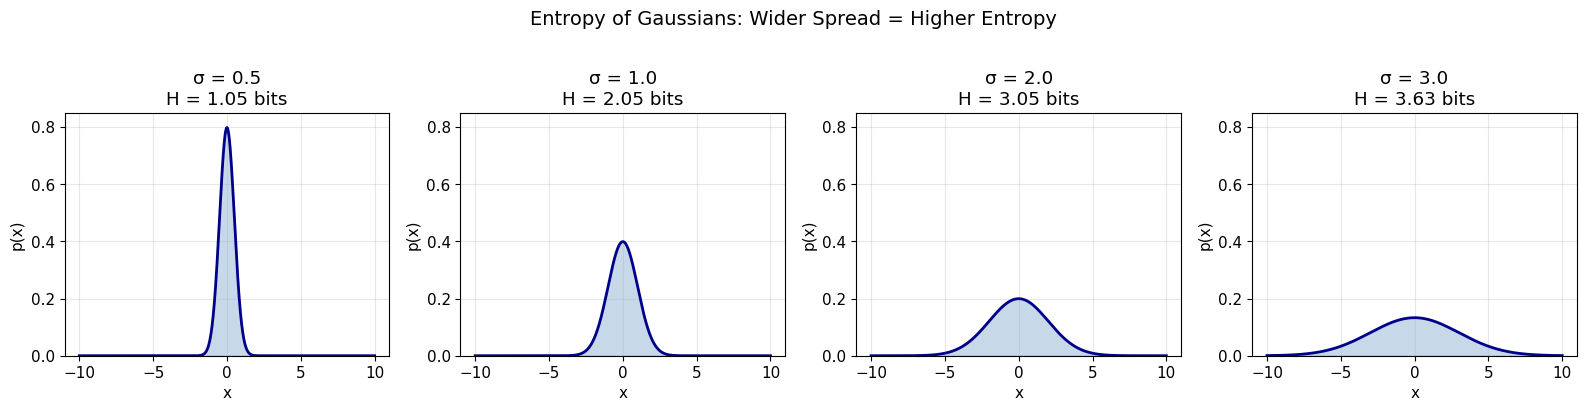

Key insight: A wider (more uncertain) Gaussian has higher entropy.
This mirrors the discrete case: more spread out = more unpredictable.


In [8]:
# For continuous distributions, we use differential entropy
# For Gaussian: H = 0.5 * log2(2 * π * e * σ²)

def gaussian_entropy(sigma):
    """Differential entropy of Gaussian with std sigma"""
    return 0.5 * np.log2(2 * np.pi * np.e * sigma**2)

# Compare Gaussians with different standard deviations
sigmas = [0.5, 1.0, 2.0, 3.0]
x = np.linspace(-10, 10, 1000)

fig, axes = plt.subplots(1, len(sigmas), figsize=(16, 4))

for idx, sigma in enumerate(sigmas):
    # Gaussian PDF
    pdf = stats.norm.pdf(x, loc=0, scale=sigma)
    H = gaussian_entropy(sigma)
    
    axes[idx].plot(x, pdf, linewidth=2, color='darkblue')
    axes[idx].fill_between(x, pdf, alpha=0.3, color='steelblue')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('p(x)')
    axes[idx].set_title(f'σ = {sigma:.1f}\nH = {H:.2f} bits')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim([0, 0.85])

fig.suptitle('Entropy of Gaussians: Wider Spread = Higher Entropy', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Key insight: A wider (more uncertain) Gaussian has higher entropy.")
print("This mirrors the discrete case: more spread out = more unpredictable.")

### Key Insight

**Entropy measures average unpredictability**: 
- High entropy = outcomes are spread out, hard to predict
- Low entropy = outcomes are concentrated, easy to predict
- Zero entropy = deterministic, no uncertainty

Think of entropy as the "minimum average surprise" you'll experience when sampling from a distribution.

## 5. Cross-Entropy: Using the Wrong Distribution

### The Core Intuition

Now comes a crucial twist: **What if we use the wrong probability distribution to measure surprise?**

**Analogies:**
1. **Wrong weather forecast**: 
   - True: 70% rain, 30% sun in Seattle
   - You believe: 30% rain, 70% sun
   - When it rains (often), you're repeatedly surprised because YOU thought it was unlikely
   - Your average surprise is higher than someone with the correct forecast

2. **Wrong map scale**:
   - True map: 1 inch = 1 mile
   - Your map: 1 inch = 10 miles  
   - You think places are farther than they are
   - You consistently over/underestimate distances

3. **Language model**:
   - True distribution: English text (e is common, q is rare)
   - Your model: Thinks all letters are equally likely
   - When encoding English text with your model, you use more bits than necessary

**The pattern**: If we use distribution $Q$ to estimate the surprise of events from distribution $P$, we'll typically be more surprised (use more bits) than if we had used $P$ itself.

**Mathematical definition**: Cross-entropy $H(P, Q)$ is the expected surprise under $P$ using information content from $Q$:

$$H(P, Q) = -\sum_{x} p(x) \log_2 q(x)$$

- Events occur according to $P$ (the true distribution)
- But we measure surprise using $Q$ (our model/belief)

### Why Is Cross-Entropy Important?

Cross-entropy is everywhere in machine learning:

- **Classification loss**: True labels are $P$, model predictions are $Q$. We minimize $H(P, Q)$ to make $Q$ closer to $P$
- **Language modeling**: True text distribution is $P$, model distribution is $Q$. Lower cross-entropy = better model
- **Compression**: Using $Q$ to compress data from $P$ costs $H(P, Q)$ bits on average

Let's see this in action.

In [9]:
def cross_entropy(p, q):
    """Compute cross-entropy H(P, Q) in bits."""
    # Only sum over events where p > 0 (events that actually occur)
    mask = p > 0
    return -np.sum(p[mask] * np.log2(q[mask]))

# True distribution: biased coin (70% heads)
p_true = np.array([0.7, 0.3])  # [heads, tails]

# Scenario 1: We know the true distribution
q_perfect = np.array([0.7, 0.3])
H_p = entropy(p_true)
H_pq_perfect = cross_entropy(p_true, q_perfect)

print("=== Scenario 1: Perfect Knowledge ===")
print(f"True distribution P: {p_true}")
print(f"Our model Q: {q_perfect}")
print(f"Entropy H(P): {H_p:.4f} bits")
print(f"Cross-entropy H(P,Q): {H_pq_perfect:.4f} bits")
print(f"Extra cost: {H_pq_perfect - H_p:.4f} bits\n")

# Scenario 2: We think it's a fair coin
q_fair = np.array([0.5, 0.5])
H_pq_fair = cross_entropy(p_true, q_fair)

print("=== Scenario 2: Wrong Belief (Fair Coin) ===")
print(f"True distribution P: {p_true}")
print(f"Our model Q: {q_fair}")
print(f"Entropy H(P): {H_p:.4f} bits")
print(f"Cross-entropy H(P,Q): {H_pq_fair:.4f} bits")
print(f"Extra cost: {H_pq_fair - H_p:.4f} bits\n")

# Scenario 3: We think it's biased the OTHER way
q_backwards = np.array([0.3, 0.7])
H_pq_backwards = cross_entropy(p_true, q_backwards)

print("=== Scenario 3: Badly Wrong (Reversed) ===")
print(f"True distribution P: {p_true}")
print(f"Our model Q: {q_backwards}")
print(f"Entropy H(P): {H_p:.4f} bits")
print(f"Cross-entropy H(P,Q): {H_pq_backwards:.4f} bits")
print(f"Extra cost: {H_pq_backwards - H_p:.4f} bits")

=== Scenario 1: Perfect Knowledge ===
True distribution P: [0.7 0.3]
Our model Q: [0.7 0.3]
Entropy H(P): 0.8813 bits
Cross-entropy H(P,Q): 0.8813 bits
Extra cost: 0.0000 bits

=== Scenario 2: Wrong Belief (Fair Coin) ===
True distribution P: [0.7 0.3]
Our model Q: [0.5 0.5]
Entropy H(P): 0.8813 bits
Cross-entropy H(P,Q): 1.0000 bits
Extra cost: 0.1187 bits

=== Scenario 3: Badly Wrong (Reversed) ===
True distribution P: [0.7 0.3]
Our model Q: [0.3 0.7]
Entropy H(P): 0.8813 bits
Cross-entropy H(P,Q): 1.3702 bits
Extra cost: 0.4890 bits


**Key observations**:
- When $Q = P$: Cross-entropy equals entropy (no extra cost)
- When $Q \neq P$: Cross-entropy > entropy (we pay a penalty for being wrong)
- The worse our model, the higher the cross-entropy

### Visualizing the Gap

Let's visualize how cross-entropy changes as our model $Q$ diverges from the true distribution $P$.

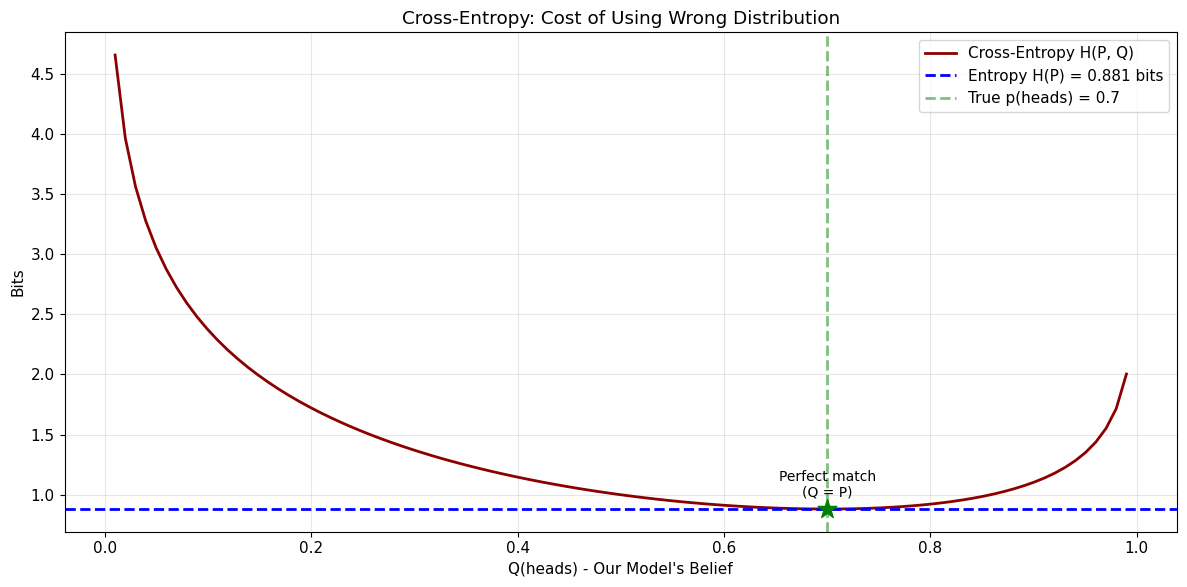

Notice: Cross-entropy is minimized when Q = P (the green star).
As our model Q deviates from P, cross-entropy increases.
This gap is what we'll call KL divergence!


In [10]:
# Fix true distribution
p_true = np.array([0.7, 0.3])
H_p = entropy(p_true)

# Vary Q from [0, 1] to [1, 0]
q_heads_probs = np.linspace(0.01, 0.99, 100)
cross_entropies = []

for q_heads in q_heads_probs:
    q = np.array([q_heads, 1 - q_heads])
    cross_entropies.append(cross_entropy(p_true, q))

plt.figure(figsize=(12, 6))
plt.plot(q_heads_probs, cross_entropies, linewidth=2, label='Cross-Entropy H(P, Q)', color='darkred')
plt.axhline(H_p, color='blue', linestyle='--', linewidth=2, label=f'Entropy H(P) = {H_p:.3f} bits')
plt.axvline(0.7, color='green', linestyle='--', alpha=0.5, label='True p(heads) = 0.7')

plt.xlabel('Q(heads) - Our Model\'s Belief')
plt.ylabel('Bits')
plt.title('Cross-Entropy: Cost of Using Wrong Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

# Highlight key points
plt.scatter([0.7], [H_p], color='green', s=200, zorder=5, marker='*')
plt.text(0.7, H_p + 0.1, 'Perfect match\n(Q = P)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Notice: Cross-entropy is minimized when Q = P (the green star).")
print("As our model Q deviates from P, cross-entropy increases.")
print("This gap is what we'll call KL divergence!")

### Cross-Entropy as a Loss Function

In machine learning, we often use cross-entropy as a loss function. Let's see a concrete example with classification.

In [11]:
# Suppose we're classifying images into 3 categories: cat, dog, bird
# True label: cat (one-hot encoded as [1, 0, 0])
p_true = torch.tensor([[1.0, 0.0, 0.0]])  # True distribution (deterministic)

# Model prediction 1: Confident and correct
q_confident_correct = torch.tensor([[0.9, 0.05, 0.05]])
loss_1 = F.cross_entropy(
    torch.log(q_confident_correct),  # F.cross_entropy expects log-probabilities
    torch.tensor([0]),  # True class index
    reduction='none'
)

# Model prediction 2: Uncertain but correct
q_uncertain_correct = torch.tensor([[0.5, 0.3, 0.2]])
loss_2 = F.cross_entropy(
    torch.log(q_uncertain_correct),
    torch.tensor([0]),
    reduction='none'
)

# Model prediction 3: Confident and wrong
q_confident_wrong = torch.tensor([[0.05, 0.9, 0.05]])
loss_3 = F.cross_entropy(
    torch.log(q_confident_wrong),
    torch.tensor([0]),
    reduction='none'
)

print("=== Classification Example ===")
print(f"True label: cat (index 0)\n")
print(f"Prediction 1 - Confident & Correct {q_confident_correct[0].numpy()}")
print(f"  Loss: {loss_1.item():.3f}\n")
print(f"Prediction 2 - Uncertain & Correct {q_uncertain_correct[0].numpy()}")
print(f"  Loss: {loss_2.item():.3f}\n")
print(f"Prediction 3 - Confident & Wrong {q_confident_wrong[0].numpy()}")
print(f"  Loss: {loss_3.item():.3f}\n")

print("Key insight: Cross-entropy loss is low when our model Q is close to the true P.")
print("Training minimizes this loss, effectively making Q converge toward P!")

=== Classification Example ===
True label: cat (index 0)

Prediction 1 - Confident & Correct [0.9  0.05 0.05]
  Loss: 0.105

Prediction 2 - Uncertain & Correct [0.5 0.3 0.2]
  Loss: 0.693

Prediction 3 - Confident & Wrong [0.05 0.9  0.05]
  Loss: 2.996

Key insight: Cross-entropy loss is low when our model Q is close to the true P.
Training minimizes this loss, effectively making Q converge toward P!


### Key Insight

**Cross-entropy measures the cost of using the wrong distribution**:
- $H(P, Q)$ is the average surprise when events follow $P$ but we use $Q$ to measure surprise
- It's always $\geq H(P)$ (the true entropy)
- When $Q = P$, cross-entropy equals entropy
- When $Q \neq P$, we pay an extra cost

**This extra cost is KL divergence!** Let's formalize it next.

## 6. KL Divergence: The Gap

### The Core Intuition

We've built up all the pieces. Now comes the key insight:

**KL Divergence = Cross-Entropy - Entropy**

$$D_{KL}(P \| Q) = H(P, Q) - H(P) = \sum_{x} p(x) \log_2 \frac{p(x)}{q(x)}$$

**What does this mean?**
- $H(P)$: The minimum bits needed to encode $P$ (using the optimal code)
- $H(P, Q)$: The bits we actually use when we use $Q$ to encode $P$
- $D_{KL}(P \| Q)$: The **extra bits wasted** by using $Q$ instead of $P$

**Analogies:**
1. **Compression**: KL divergence is the extra storage cost when using a suboptimal compression scheme
2. **Surprise**: KL divergence is how much MORE surprised we are on average when using the wrong model
3. **Distance**: KL divergence measures how "far" distribution $Q$ is from $P$ (though it's not a true distance - more on this soon)

### Computing KL Divergence

Let's compute KL divergence for our earlier examples.

In [12]:
def kl_divergence(p, q):
    """Compute KL divergence D_KL(P || Q) in bits."""
    mask = p > 0
    return np.sum(p[mask] * np.log2(p[mask] / q[mask]))

# True distribution: biased coin
p_true = np.array([0.7, 0.3])

# Test cases
test_cases = [
    ("Perfect model (Q = P)", np.array([0.7, 0.3])),
    ("Fair coin model", np.array([0.5, 0.5])),
    ("Reversed model", np.array([0.3, 0.7])),
    ("Nearly perfect", np.array([0.69, 0.31])),
    ("Very wrong", np.array([0.1, 0.9])),
]

print("=== KL Divergence Examples ===")
print(f"True distribution P: {p_true}\n")

for name, q in test_cases:
    H_p = entropy(p_true)
    H_pq = cross_entropy(p_true, q)
    kl = kl_divergence(p_true, q)
    
    print(f"{name}")
    print(f"  Q: {q}")
    print(f"  H(P): {H_p:.4f} bits")
    print(f"  H(P,Q): {H_pq:.4f} bits")
    print(f"  D_KL(P||Q): {kl:.4f} bits")
    print(f"  → {kl * 100:.2f}% extra bits wasted\n")

=== KL Divergence Examples ===
True distribution P: [0.7 0.3]

Perfect model (Q = P)
  Q: [0.7 0.3]
  H(P): 0.8813 bits
  H(P,Q): 0.8813 bits
  D_KL(P||Q): 0.0000 bits
  → 0.00% extra bits wasted

Fair coin model
  Q: [0.5 0.5]
  H(P): 0.8813 bits
  H(P,Q): 1.0000 bits
  D_KL(P||Q): 0.1187 bits
  → 11.87% extra bits wasted

Reversed model
  Q: [0.3 0.7]
  H(P): 0.8813 bits
  H(P,Q): 1.3702 bits
  D_KL(P||Q): 0.4890 bits
  → 48.90% extra bits wasted

Nearly perfect
  Q: [0.69 0.31]
  H(P): 0.8813 bits
  H(P,Q): 0.8816 bits
  D_KL(P||Q): 0.0003 bits
  → 0.03% extra bits wasted

Very wrong
  Q: [0.1 0.9]
  H(P): 0.8813 bits
  H(P,Q): 2.3710 bits
  D_KL(P||Q): 1.4897 bits
  → 148.97% extra bits wasted



**Key observations**:
- $D_{KL}(P \| Q) = 0$ if and only if $P = Q$
- $D_{KL}(P \| Q) > 0$ otherwise
- Larger KL divergence = distributions are more different

### Important: KL Divergence is Asymmetric

Unlike distance metrics (where $d(A, B) = d(B, A)$), KL divergence is **not symmetric**:

$$D_{KL}(P \| Q) \neq D_{KL}(Q \| P)$$

This is why we use the notation $\|$ instead of a comma. Let's see this in action.

In [13]:
p = np.array([0.7, 0.3])
q = np.array([0.3, 0.7])

kl_pq = kl_divergence(p, q)
kl_qp = kl_divergence(q, p)

print("=== Asymmetry of KL Divergence ===")
print(f"P: {p}")
print(f"Q: {q}\n")
print(f"D_KL(P || Q): {kl_pq:.4f} bits")
print(f"D_KL(Q || P): {kl_qp:.4f} bits\n")
print(f"Are they equal? {np.isclose(kl_pq, kl_qp)}")
print(f"\nWhy? Because we're measuring different things:")
print(f"  D_KL(P || Q): Extra bits when Q encodes events from P")
print(f"  D_KL(Q || P): Extra bits when P encodes events from Q")

=== Asymmetry of KL Divergence ===
P: [0.7 0.3]
Q: [0.3 0.7]

D_KL(P || Q): 0.4890 bits
D_KL(Q || P): 0.4890 bits

Are they equal? True

Why? Because we're measuring different things:
  D_KL(P || Q): Extra bits when Q encodes events from P
  D_KL(Q || P): Extra bits when P encodes events from Q


**Intuition for asymmetry**:
- $D_{KL}(P \| Q)$: Events happen according to $P$. We measure surprise using $Q$. 
  - If $P$ puts mass where $Q$ doesn't → HUGE penalty
- $D_{KL}(Q \| P)$: Events happen according to $Q$. We measure surprise using $P$.
  - Different events, different weights, different penalty

This asymmetry matters in ML! Choose the direction based on what you're optimizing.

### Visualizing KL Divergence

Let's visualize how KL divergence changes as we vary $Q$ while keeping $P$ fixed.

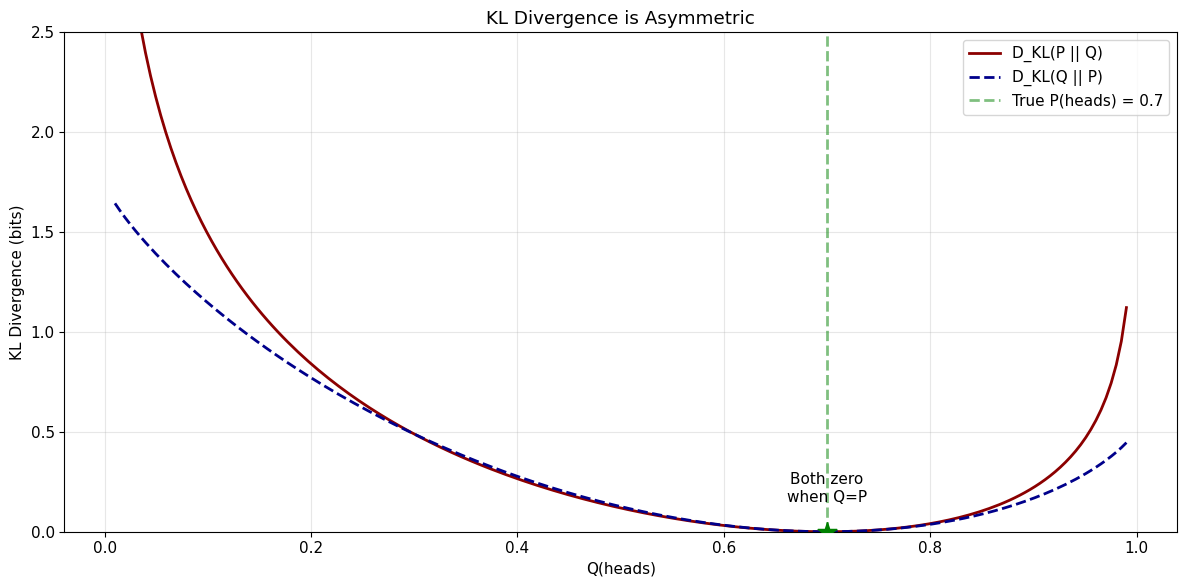

Notice: Both curves reach zero at Q=P, but have different shapes elsewhere.
This asymmetry is fundamental to KL divergence!


In [14]:
# Fix P
p_true = np.array([0.7, 0.3])

# Vary Q
q_heads_probs = np.linspace(0.01, 0.99, 200)
kl_forward = []  # D_KL(P || Q)
kl_reverse = []  # D_KL(Q || P)

for q_heads in q_heads_probs:
    q = np.array([q_heads, 1 - q_heads])
    kl_forward.append(kl_divergence(p_true, q))
    kl_reverse.append(kl_divergence(q, p_true))

plt.figure(figsize=(12, 6))
plt.plot(q_heads_probs, kl_forward, linewidth=2, label='D_KL(P || Q)', color='darkred')
plt.plot(q_heads_probs, kl_reverse, linewidth=2, label='D_KL(Q || P)', color='darkblue', linestyle='--')
plt.axvline(0.7, color='green', linestyle='--', alpha=0.5, label='True P(heads) = 0.7')

plt.xlabel('Q(heads)')
plt.ylabel('KL Divergence (bits)')
plt.title('KL Divergence is Asymmetric')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([0, 2.5])

# Mark the minimum
plt.scatter([0.7], [0], color='green', s=200, zorder=5, marker='*')
plt.text(0.7, 0.15, 'Both zero\nwhen Q=P', ha='center')

plt.tight_layout()
plt.show()

print("Notice: Both curves reach zero at Q=P, but have different shapes elsewhere.")
print("This asymmetry is fundamental to KL divergence!")

### Properties of KL Divergence

Let's verify the key mathematical properties.

In [15]:
print("=== Properties of KL Divergence ===")
print()

# Property 1: Non-negativity
print("1. Non-negativity: D_KL(P || Q) >= 0")
p_test = np.array([0.3, 0.5, 0.2])
q_test = np.array([0.4, 0.3, 0.3])
kl_test = kl_divergence(p_test, q_test)
print(f"   Example: D_KL({p_test} || {q_test}) = {kl_test:.4f} >= 0 ✓")
print()

# Property 2: Zero iff P = Q
print("2. Zero if and only if P = Q")
p_same = np.array([0.3, 0.5, 0.2])
q_same = np.array([0.3, 0.5, 0.2])
kl_same = kl_divergence(p_same, q_same)
print(f"   D_KL(P || P) = {kl_same:.10f} ≈ 0 ✓")
print()

# Property 3: Asymmetry
print("3. Asymmetry: D_KL(P || Q) != D_KL(Q || P)")
kl_pq = kl_divergence(p_test, q_test)
kl_qp = kl_divergence(q_test, p_test)
print(f"   D_KL(P || Q) = {kl_pq:.4f}")
print(f"   D_KL(Q || P) = {kl_qp:.4f}")
print(f"   Equal? {np.isclose(kl_pq, kl_qp)} (Generally false) ✓")
print()

# Property 4: Not a distance metric (fails triangle inequality)
print("4. NOT a distance metric (fails triangle inequality)")
p1 = np.array([0.8, 0.2])
p2 = np.array([0.5, 0.5])
p3 = np.array([0.2, 0.8])
kl_12 = kl_divergence(p1, p2)
kl_23 = kl_divergence(p2, p3)
kl_13 = kl_divergence(p1, p3)
print(f"   D_KL(P1 || P2) = {kl_12:.4f}")
print(f"   D_KL(P2 || P3) = {kl_23:.4f}")
print(f"   D_KL(P1 || P3) = {kl_13:.4f}")
print(f"   Triangle inequality: {kl_12:.4f} + {kl_23:.4f} = {kl_12 + kl_23:.4f} >= {kl_13:.4f}?")
print(f"   (Doesn't always hold - it's a divergence, not a distance)")

=== Properties of KL Divergence ===

1. Non-negativity: D_KL(P || Q) >= 0
   Example: D_KL([0.3 0.5 0.2] || [0.4 0.3 0.3]) = 0.1270 >= 0 ✓

2. Zero if and only if P = Q
   D_KL(P || P) = 0.0000000000 ≈ 0 ✓

3. Asymmetry: D_KL(P || Q) != D_KL(Q || P)
   D_KL(P || Q) = 0.1270
   D_KL(Q || P) = 0.1204
   Equal? False (Generally false) ✓

4. NOT a distance metric (fails triangle inequality)
   D_KL(P1 || P2) = 0.2781
   D_KL(P2 || P3) = 0.3219
   D_KL(P1 || P3) = 1.2000
   Triangle inequality: 0.2781 + 0.3219 = 0.6000 >= 1.2000?
   (Doesn't always hold - it's a divergence, not a distance)


### Key Insight

**KL divergence measures how different two distributions are**:
- $D_{KL}(P \| Q)$ is the extra bits needed when using $Q$ to encode events from $P$
- Zero if and only if $P = Q$
- Always non-negative
- **Asymmetric**: $D_{KL}(P \| Q) \neq D_{KL}(Q \| P)$
- Not a distance metric, but a divergence

Think of it as the "cost of being wrong" about the distribution.

## 7. Visual Intuitions

### Comparing Gaussian Distributions

Let's build intuition with continuous distributions. We'll compare Gaussians with different means and variances.

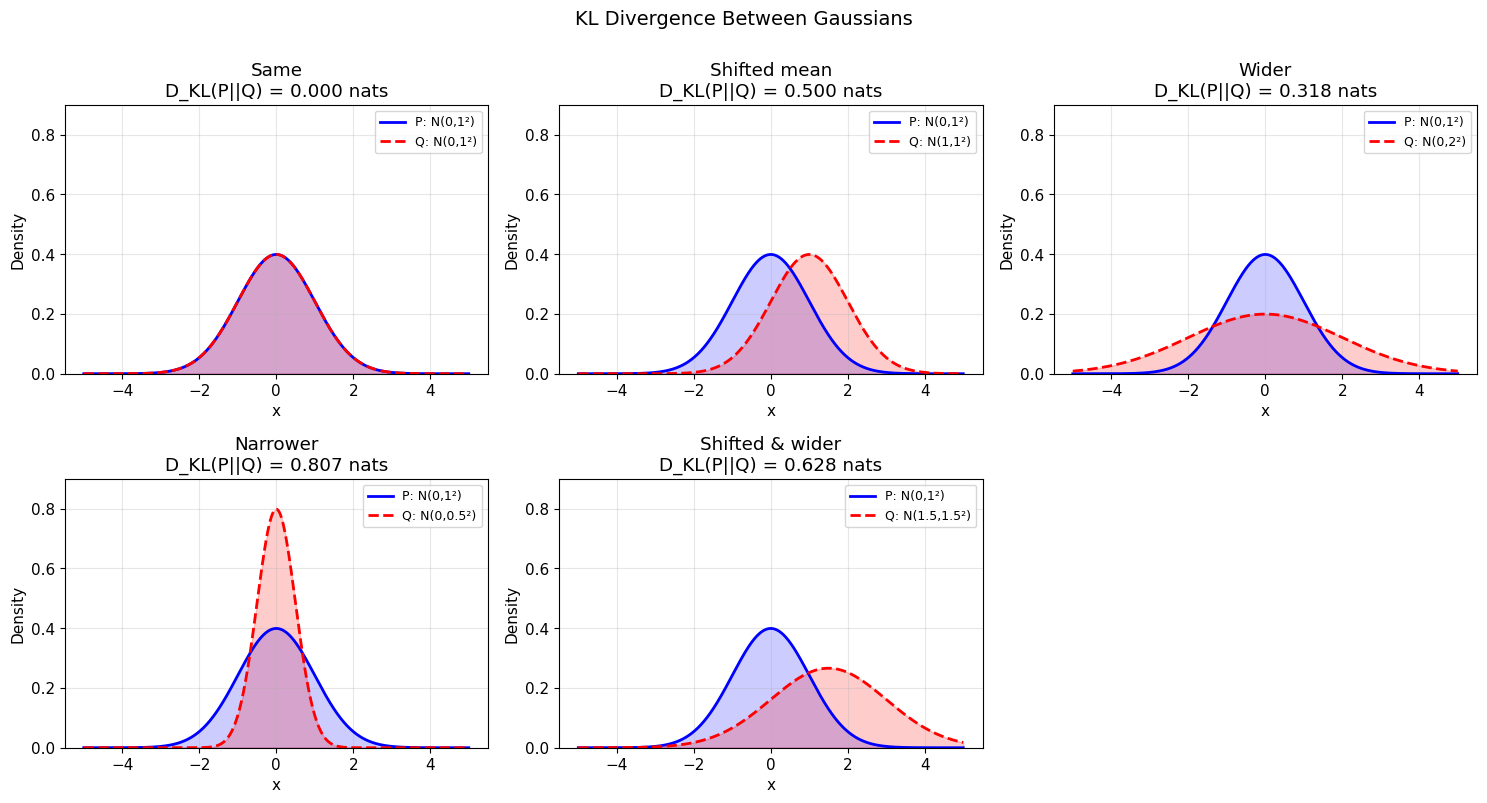

Notice:
- KL = 0 when distributions are identical
- Larger shifts → larger KL
- Variance mismatch also increases KL
- Both mean and variance contribute to divergence


In [16]:
def kl_gaussian(mu1, sigma1, mu2, sigma2):
    """KL divergence between two Gaussians: D_KL(N(mu1, sigma1²) || N(mu2, sigma2²))"""
    return np.log(sigma2 / sigma1) + (sigma1**2 + (mu1 - mu2)**2) / (2 * sigma2**2) - 0.5

# Reference distribution: N(0, 1)
mu_p, sigma_p = 0, 1
x = np.linspace(-5, 5, 1000)
p_dist = stats.norm.pdf(x, mu_p, sigma_p)

# Test different Q distributions
test_cases = [
    ("Same", 0, 1),
    ("Shifted mean", 1, 1),
    ("Wider", 0, 2),
    ("Narrower", 0, 0.5),
    ("Shifted & wider", 1.5, 1.5),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (name, mu_q, sigma_q) in enumerate(test_cases):
    q_dist = stats.norm.pdf(x, mu_q, sigma_q)
    kl = kl_gaussian(mu_p, sigma_p, mu_q, sigma_q)
    
    axes[idx].plot(x, p_dist, linewidth=2, label=f'P: N({mu_p},{sigma_p}²)', color='blue')
    axes[idx].plot(x, q_dist, linewidth=2, label=f'Q: N({mu_q},{sigma_q}²)', color='red', linestyle='--')
    axes[idx].fill_between(x, p_dist, alpha=0.2, color='blue')
    axes[idx].fill_between(x, q_dist, alpha=0.2, color='red')
    axes[idx].set_title(f'{name}\nD_KL(P||Q) = {kl:.3f} nats')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('Density')
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim([0, 0.9])

# Remove extra subplot
fig.delaxes(axes[5])

fig.suptitle('KL Divergence Between Gaussians', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print("Notice:")
print("- KL = 0 when distributions are identical")
print("- Larger shifts → larger KL")
print("- Variance mismatch also increases KL")
print("- Both mean and variance contribute to divergence")

### Interactive Exploration: How Does KL Change?

Let's visualize how KL divergence changes as we move $Q$ away from $P$ in different ways.

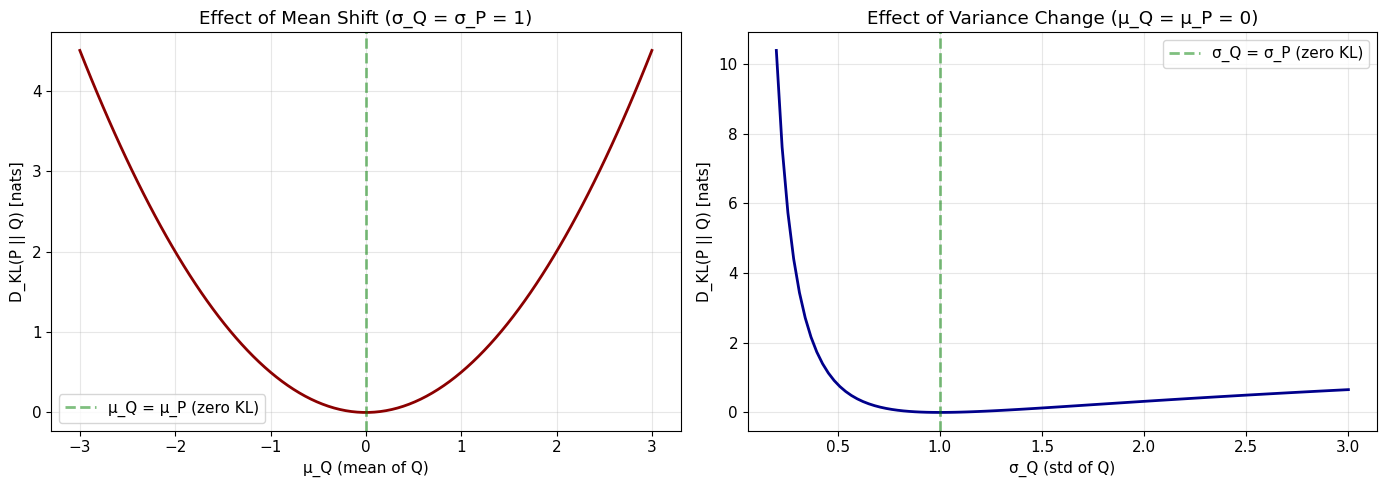

Key observations:
1. Mean shift: KL grows quadratically with distance (parabola)
2. Variance change: KL is asymmetric around σ_Q = σ_P
   - Making Q wider (σ_Q > σ_P) increases KL gradually
   - Making Q narrower (σ_Q < σ_P) increases KL more sharply
3. Both effects contribute when both mean and variance differ


In [17]:
# Fix P: N(0, 1)
mu_p, sigma_p = 0, 1

# Vary Q's mean while keeping sigma=1
mu_q_values = np.linspace(-3, 3, 100)
kl_mean_shift = [kl_gaussian(mu_p, sigma_p, mu_q, sigma_p) for mu_q in mu_q_values]

# Vary Q's sigma while keeping mu=0  
sigma_q_values = np.linspace(0.2, 3, 100)
kl_sigma_change = [kl_gaussian(mu_p, sigma_p, mu_p, sigma_q) for sigma_q in sigma_q_values]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean shift
ax1.plot(mu_q_values, kl_mean_shift, linewidth=2, color='darkred')
ax1.axvline(0, color='green', linestyle='--', alpha=0.5, label='μ_Q = μ_P (zero KL)')
ax1.set_xlabel('μ_Q (mean of Q)')
ax1.set_ylabel('D_KL(P || Q) [nats]')
ax1.set_title('Effect of Mean Shift (σ_Q = σ_P = 1)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Sigma change
ax2.plot(sigma_q_values, kl_sigma_change, linewidth=2, color='darkblue')
ax2.axvline(1, color='green', linestyle='--', alpha=0.5, label='σ_Q = σ_P (zero KL)')
ax2.set_xlabel('σ_Q (std of Q)')
ax2.set_ylabel('D_KL(P || Q) [nats]')
ax2.set_title('Effect of Variance Change (μ_Q = μ_P = 0)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key observations:")
print("1. Mean shift: KL grows quadratically with distance (parabola)")
print("2. Variance change: KL is asymmetric around σ_Q = σ_P")
print("   - Making Q wider (σ_Q > σ_P) increases KL gradually")
print("   - Making Q narrower (σ_Q < σ_P) increases KL more sharply")
print("3. Both effects contribute when both mean and variance differ")

### Heatmap: KL Divergence Landscape

Let's create a 2D heatmap showing KL divergence as both mean and variance of $Q$ vary.

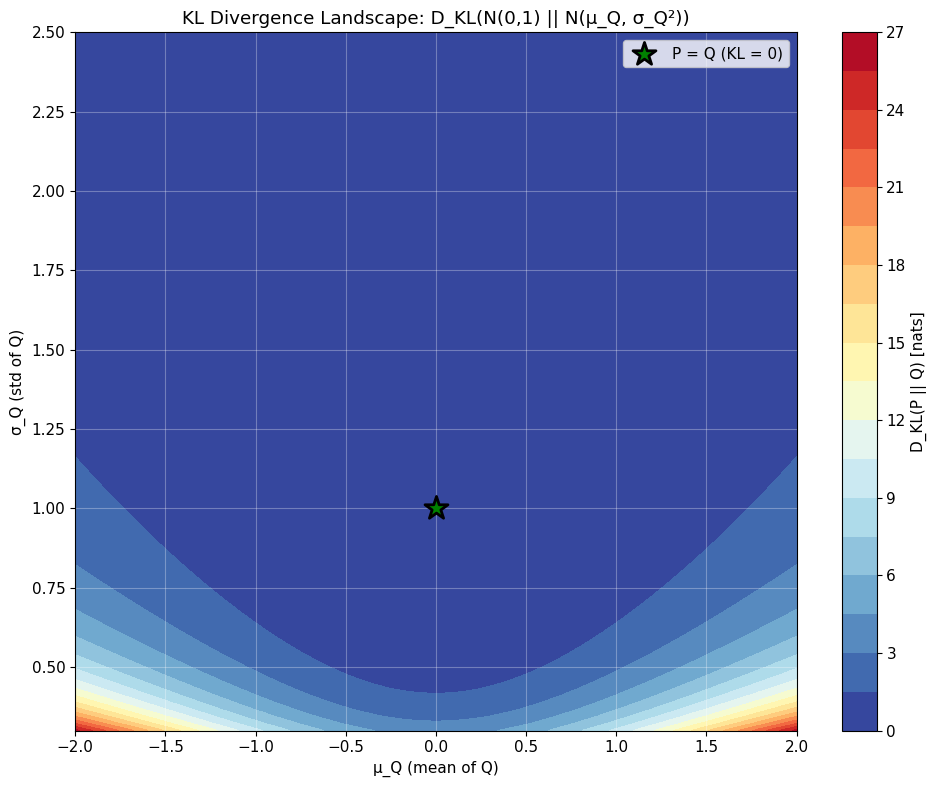

Interpretation:
- Darker blue = Lower KL (distributions are similar)
- Brighter red = Higher KL (distributions are different)
- The green star marks zero KL (where Q = P)
- KL increases in all directions away from this point


In [18]:
# Fix P: N(0, 1)
mu_p, sigma_p = 0, 1

# Create grid of Q parameters
mu_q_range = np.linspace(-2, 2, 100)
sigma_q_range = np.linspace(0.3, 2.5, 100)
MU, SIGMA = np.meshgrid(mu_q_range, sigma_q_range)

# Compute KL for each point
KL = np.zeros_like(MU)
for i in range(MU.shape[0]):
    for j in range(MU.shape[1]):
        KL[i, j] = kl_gaussian(mu_p, sigma_p, MU[i, j], SIGMA[i, j])

plt.figure(figsize=(10, 8))
contour = plt.contourf(MU, SIGMA, KL, levels=20, cmap='RdYlBu_r')
plt.colorbar(contour, label='D_KL(P || Q) [nats]')

# Mark the minimum (P = Q)
plt.scatter([mu_p], [sigma_p], color='green', s=300, marker='*', 
           edgecolors='black', linewidths=2, zorder=5, label='P = Q (KL = 0)')

plt.xlabel('μ_Q (mean of Q)')
plt.ylabel('σ_Q (std of Q)')
plt.title('KL Divergence Landscape: D_KL(N(0,1) || N(μ_Q, σ_Q²))')
plt.legend()
plt.grid(True, alpha=0.3, color='white')
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Darker blue = Lower KL (distributions are similar)")
print("- Brighter red = Higher KL (distributions are different)")
print("- The green star marks zero KL (where Q = P)")
print("- KL increases in all directions away from this point")

## 8. Applications in Machine Learning

Now that we understand KL divergence intuitively, let's see where it appears in real ML systems.

### Application 1: Variational Autoencoders (VAEs)

VAEs learn a latent representation by maximizing the evidence lower bound (ELBO):

$$\text{ELBO} = \mathbb{E}_{q(z|x)}[\log p(x|z)] - D_{KL}(q(z|x) \| p(z))$$

The KL term regularizes the learned distribution $q(z|x)$ to stay close to the prior $p(z)$ (usually standard normal).

**Why?** Without this term, the encoder could map each input to a completely separate region, making the decoder fail on unseen latent codes. KL divergence keeps the latent space well-behaved.

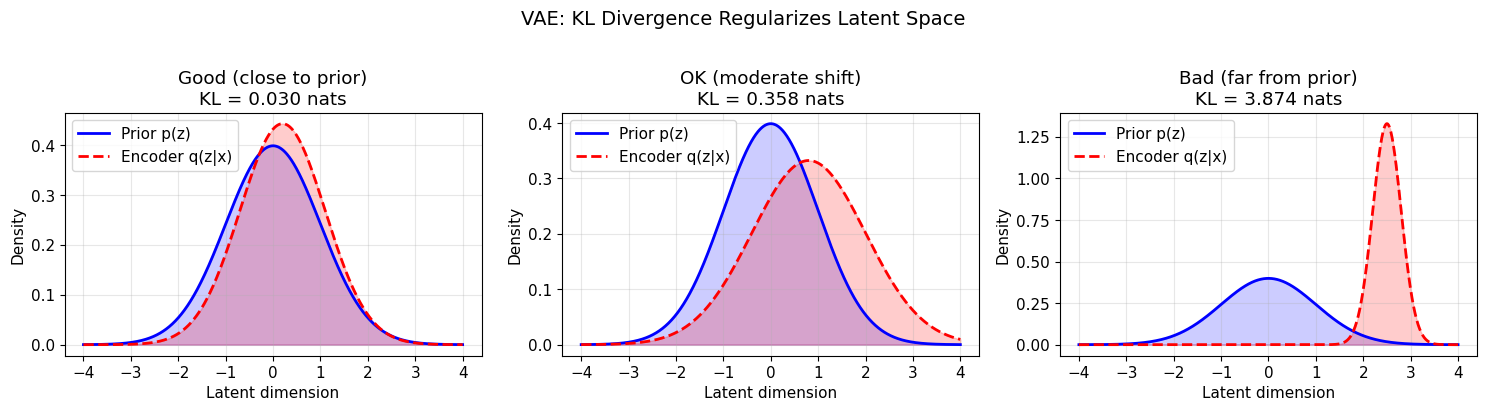

In VAEs:
- Low KL: Encoder stays close to prior (good for generation)
- High KL: Encoder deviates (may learn better representations but worse generation)
- Trade-off: Reconstruction quality vs. KL penalty (controlled by β-VAE)


In [19]:
# Simulate VAE latent distributions
# Prior: N(0, 1)
prior_mu, prior_sigma = 0, 1

# Encoder outputs for different data points
encoded_distributions = [
    ("Good (close to prior)", 0.2, 0.9),
    ("OK (moderate shift)", 0.8, 1.2),
    ("Bad (far from prior)", 2.5, 0.3),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x = np.linspace(-4, 4, 1000)
prior_dist = stats.norm.pdf(x, prior_mu, prior_sigma)

for idx, (name, mu_q, sigma_q) in enumerate(encoded_distributions):
    q_dist = stats.norm.pdf(x, mu_q, sigma_q)
    kl = kl_gaussian(mu_q, sigma_q, prior_mu, prior_sigma)
    
    axes[idx].plot(x, prior_dist, linewidth=2, label='Prior p(z)', color='blue')
    axes[idx].plot(x, q_dist, linewidth=2, label=f'Encoder q(z|x)', color='red', linestyle='--')
    axes[idx].fill_between(x, prior_dist, alpha=0.2, color='blue')
    axes[idx].fill_between(x, q_dist, alpha=0.2, color='red')
    axes[idx].set_title(f'{name}\nKL = {kl:.3f} nats')
    axes[idx].set_xlabel('Latent dimension')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

fig.suptitle('VAE: KL Divergence Regularizes Latent Space', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("In VAEs:")
print("- Low KL: Encoder stays close to prior (good for generation)")
print("- High KL: Encoder deviates (may learn better representations but worse generation)")
print("- Trade-off: Reconstruction quality vs. KL penalty (controlled by β-VAE)")

### Application 2: Reinforcement Learning (Policy Optimization)

In policy gradient methods like TRPO and PPO, we want to improve the policy without changing it too much:

$$\text{maximize } \mathbb{E}_{\pi_{\text{new}}}[\text{advantage}] \text{ subject to } D_{KL}(\pi_{\text{old}} \| \pi_{\text{new}}) < \delta$$

**Why?** Large policy changes can be catastrophic (agent forgets good behaviors). KL divergence bounds the change.

In [20]:
# Simulate discrete action policies
# Actions: [left, right, up, down]
policy_old = np.array([0.4, 0.3, 0.2, 0.1])

# Different policy updates
updates = [
    ("Safe update", np.array([0.42, 0.28, 0.21, 0.09])),
    ("Moderate update", np.array([0.5, 0.25, 0.15, 0.1])),
    ("Risky update", np.array([0.7, 0.15, 0.1, 0.05])),
]

print("=== RL Policy Updates ===")
print(f"Old policy: {policy_old}\n")

for name, policy_new in updates:
    kl = kl_divergence(policy_old, policy_new)
    print(f"{name}")
    print(f"  New policy: {policy_new}")
    print(f"  D_KL(π_old || π_new): {kl:.4f} bits")
    print(f"  Status: {'✓ Safe' if kl < 0.01 else '✗ Too risky' if kl > 0.1 else '⚠ Moderate'}\n")

print("In RL:")
print("- Small KL: Policy changes slowly (stable learning)")
print("- Large KL: Policy changes drastically (can forget good behaviors)")
print("- TRPO/PPO constrain KL to ensure stable learning")

=== RL Policy Updates ===
Old policy: [0.4 0.3 0.2 0.1]

Safe update
  New policy: [0.42 0.28 0.21 0.09]
  D_KL(π_old || π_new): 0.0028 bits
  Status: ✓ Safe

Moderate update
  New policy: [0.5  0.25 0.15 0.1 ]
  D_KL(π_old || π_new): 0.0331 bits
  Status: ⚠ Moderate

Risky update
  New policy: [0.7  0.15 0.1  0.05]
  D_KL(π_old || π_new): 0.2771 bits
  Status: ✗ Too risky

In RL:
- Small KL: Policy changes slowly (stable learning)
- Large KL: Policy changes drastically (can forget good behaviors)
- TRPO/PPO constrain KL to ensure stable learning


### Application 3: Model Training (Minimizing Cross-Entropy)

When training a classifier, we minimize cross-entropy loss:

$$\mathcal{L} = H(P, Q) = H(P) + D_{KL}(P \| Q)$$

Since $H(P)$ (entropy of true labels) is constant, minimizing cross-entropy is equivalent to minimizing KL divergence!

=== Training a Classifier ===
True distribution P: [1. 0. 0.]
H(P) = -0.0000 bits (constant)

Epoch 1 (random)
  Prediction Q: [0.33 0.33 0.34]
  Cross-entropy H(P,Q): 1.5995 bits
  KL divergence D_KL(P||Q): 1.5995 bits
  Relation: H(P,Q) = H(P) + D_KL(P||Q) → 1.5995 = -0.0000 + 1.5995 ✓

Epoch 5 (learning)
  Prediction Q: [0.6  0.25 0.15]
  Cross-entropy H(P,Q): 0.7370 bits
  KL divergence D_KL(P||Q): 0.7370 bits
  Relation: H(P,Q) = H(P) + D_KL(P||Q) → 0.7370 = -0.0000 + 0.7370 ✓

Epoch 10 (better)
  Prediction Q: [0.8  0.12 0.08]
  Cross-entropy H(P,Q): 0.3219 bits
  KL divergence D_KL(P||Q): 0.3219 bits
  Relation: H(P,Q) = H(P) + D_KL(P||Q) → 0.3219 = -0.0000 + 0.3219 ✓

Epoch 20 (converged)
  Prediction Q: [0.95 0.03 0.02]
  Cross-entropy H(P,Q): 0.0740 bits
  KL divergence D_KL(P||Q): 0.0740 bits
  Relation: H(P,Q) = H(P) + D_KL(P||Q) → 0.0740 = -0.0000 + 0.0740 ✓



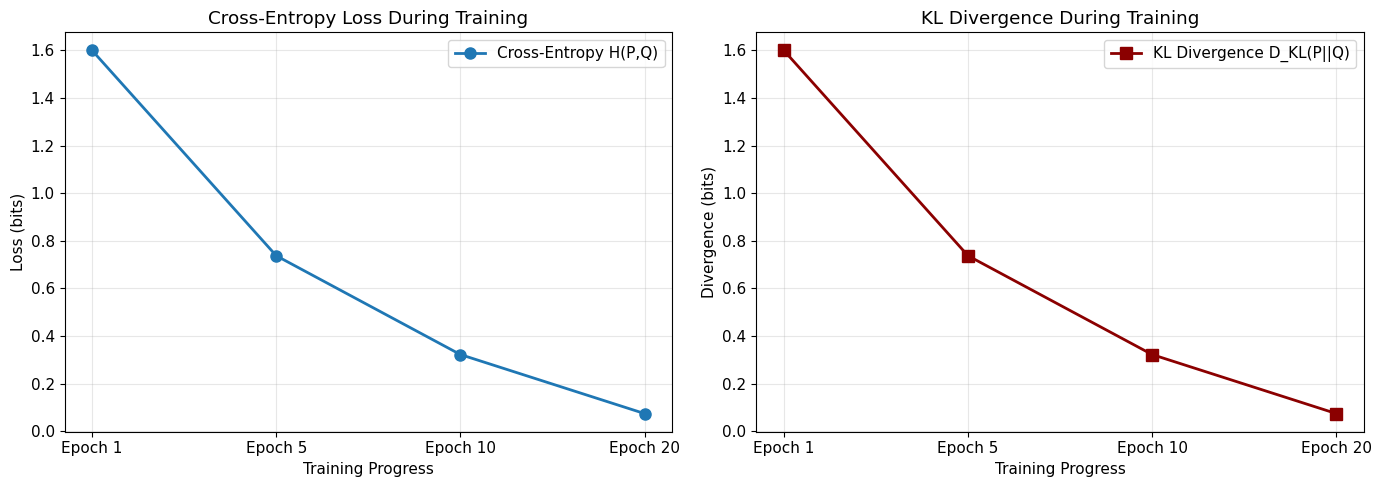

Key insight: Minimizing cross-entropy ≡ Minimizing KL divergence
As training progresses, Q approaches P, and both metrics decrease to zero.


In [21]:
# Simulate training a 3-class classifier
# True label: class 0
p_true = np.array([1.0, 0.0, 0.0])
H_p = entropy(p_true)  # Entropy of true distribution (zero for one-hot)

# Model predictions at different training stages
training_stages = [
    ("Epoch 1 (random)", np.array([0.33, 0.33, 0.34])),
    ("Epoch 5 (learning)", np.array([0.6, 0.25, 0.15])),
    ("Epoch 10 (better)", np.array([0.8, 0.12, 0.08])),
    ("Epoch 20 (converged)", np.array([0.95, 0.03, 0.02])),
]

print("=== Training a Classifier ===")
print(f"True distribution P: {p_true}")
print(f"H(P) = {H_p:.4f} bits (constant)\n")

epochs = []
cross_entropies = []
kl_divs = []

for name, q_pred in training_stages:
    H_pq = cross_entropy(p_true, q_pred)
    kl = kl_divergence(p_true, q_pred)
    
    epochs.append(name)
    cross_entropies.append(H_pq)
    kl_divs.append(kl)
    
    print(f"{name}")
    print(f"  Prediction Q: {q_pred}")
    print(f"  Cross-entropy H(P,Q): {H_pq:.4f} bits")
    print(f"  KL divergence D_KL(P||Q): {kl:.4f} bits")
    print(f"  Relation: H(P,Q) = H(P) + D_KL(P||Q) → {H_pq:.4f} = {H_p:.4f} + {kl:.4f} ✓\n")

# Plot training progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(len(epochs))
ax1.plot(x_pos, cross_entropies, marker='o', linewidth=2, markersize=8, label='Cross-Entropy H(P,Q)')
ax1.set_xlabel('Training Progress')
ax1.set_ylabel('Loss (bits)')
ax1.set_title('Cross-Entropy Loss During Training')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(['Epoch 1', 'Epoch 5', 'Epoch 10', 'Epoch 20'])
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(x_pos, kl_divs, marker='s', linewidth=2, markersize=8, 
        color='darkred', label='KL Divergence D_KL(P||Q)')
ax2.set_xlabel('Training Progress')
ax2.set_ylabel('Divergence (bits)')
ax2.set_title('KL Divergence During Training')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['Epoch 1', 'Epoch 5', 'Epoch 10', 'Epoch 20'])
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print("Key insight: Minimizing cross-entropy ≡ Minimizing KL divergence")
print("As training progresses, Q approaches P, and both metrics decrease to zero.")

### Application 4: Knowledge Distillation

When distilling a large teacher model into a smaller student model, we minimize:

$$D_{KL}(P_{\text{teacher}} \| P_{\text{student}})$$

This makes the student's output distribution match the teacher's, capturing its knowledge.

In [22]:
# Teacher model: confident, well-calibrated
teacher_probs = np.array([0.8, 0.15, 0.05])

# Student models at different training stages
students = [
    ("Random init", np.array([0.33, 0.33, 0.34])),
    ("After distillation", np.array([0.78, 0.16, 0.06])),
]

print("=== Knowledge Distillation ===")
print(f"Teacher probabilities: {teacher_probs}\n")

for name, student_probs in students:
    kl = kl_divergence(teacher_probs, student_probs)
    print(f"{name}")
    print(f"  Student probabilities: {student_probs}")
    print(f"  D_KL(Teacher || Student): {kl:.4f} bits\n")

print("The student learns to match not just the correct class, but the teacher's")
print("entire probability distribution - capturing its uncertainty and relationships!")

=== Knowledge Distillation ===
Teacher probabilities: [0.8  0.15 0.05]

Random init
  Student probabilities: [0.33 0.33 0.34]
  D_KL(Teacher || Student): 0.7131 bits

After distillation
  Student probabilities: [0.78 0.16 0.06]
  D_KL(Teacher || Student): 0.0021 bits

The student learns to match not just the correct class, but the teacher's
entire probability distribution - capturing its uncertainty and relationships!


## 9. Key Takeaways

Let's consolidate everything we've learned.

### The Building Blocks

1. **Information Content (Surprisal)**: $I(x) = -\log p(x)$
   - Rare events carry more information
   - Measured in bits (if using $\log_2$)

2. **Entropy**: $H(P) = \mathbb{E}_{x \sim P}[-\log p(x)]$
   - Average surprise in a distribution
   - Measures unpredictability/disorder
   - Minimum bits needed to encode outcomes

3. **Cross-Entropy**: $H(P, Q) = \mathbb{E}_{x \sim P}[-\log q(x)]$
   - Average surprise when events follow $P$ but we use $Q$
   - Bits needed when using the "wrong" distribution
   - Always $\geq H(P)$

4. **KL Divergence**: $D_{KL}(P \| Q) = H(P, Q) - H(P)$
   - Extra bits wasted by using $Q$ instead of $P$
   - Measures how "different" distributions are
   - Zero if and only if $P = Q$
   - Asymmetric: $D_{KL}(P \| Q) \neq D_{KL}(Q \| P)$

### Intuitive Summary

**In everyday language:**

- **Entropy**: How unpredictable is this distribution?
- **Cross-Entropy**: How surprised am I on average if I use the wrong model?
- **KL Divergence**: How much extra surprise do I get from using the wrong model?

**The compression analogy:**

Imagine you're compressing files:
- **Entropy**: The theoretical minimum file size (perfect compression)
- **Cross-Entropy**: The file size you actually get with your compression algorithm
- **KL Divergence**: The wasted bytes due to suboptimal compression

**The prediction analogy:**

Imagine you're predicting tomorrow's weather:
- **Entropy**: The inherent unpredictability of weather
- **Cross-Entropy**: Your average prediction error
- **KL Divergence**: How much worse your predictions are compared to optimal

### When to Use KL Divergence

Use KL divergence when you need to:

1. **Compare probability distributions**: Measure how different $Q$ is from $P$
2. **Regularize learning**: Keep learned distribution close to a prior (VAEs)
3. **Constrain updates**: Limit how much a policy/model can change (RL)
4. **Transfer knowledge**: Match student to teacher distributions (distillation)
5. **Evaluate models**: Lower KL = better approximation of true distribution

**Remember**:
- Direction matters! $D_{KL}(P \| Q)$ vs $D_{KL}(Q \| P)$
- Choose based on your goal:
  - $D_{KL}(P \| Q)$: Penalize $Q$ for missing mass where $P$ has mass (mode-seeking)
  - $D_{KL}(Q \| P)$: Penalize $Q$ for having mass where $P$ doesn't (mean-seeking)

### Visual Summary

Let's create one final visualization tying everything together.

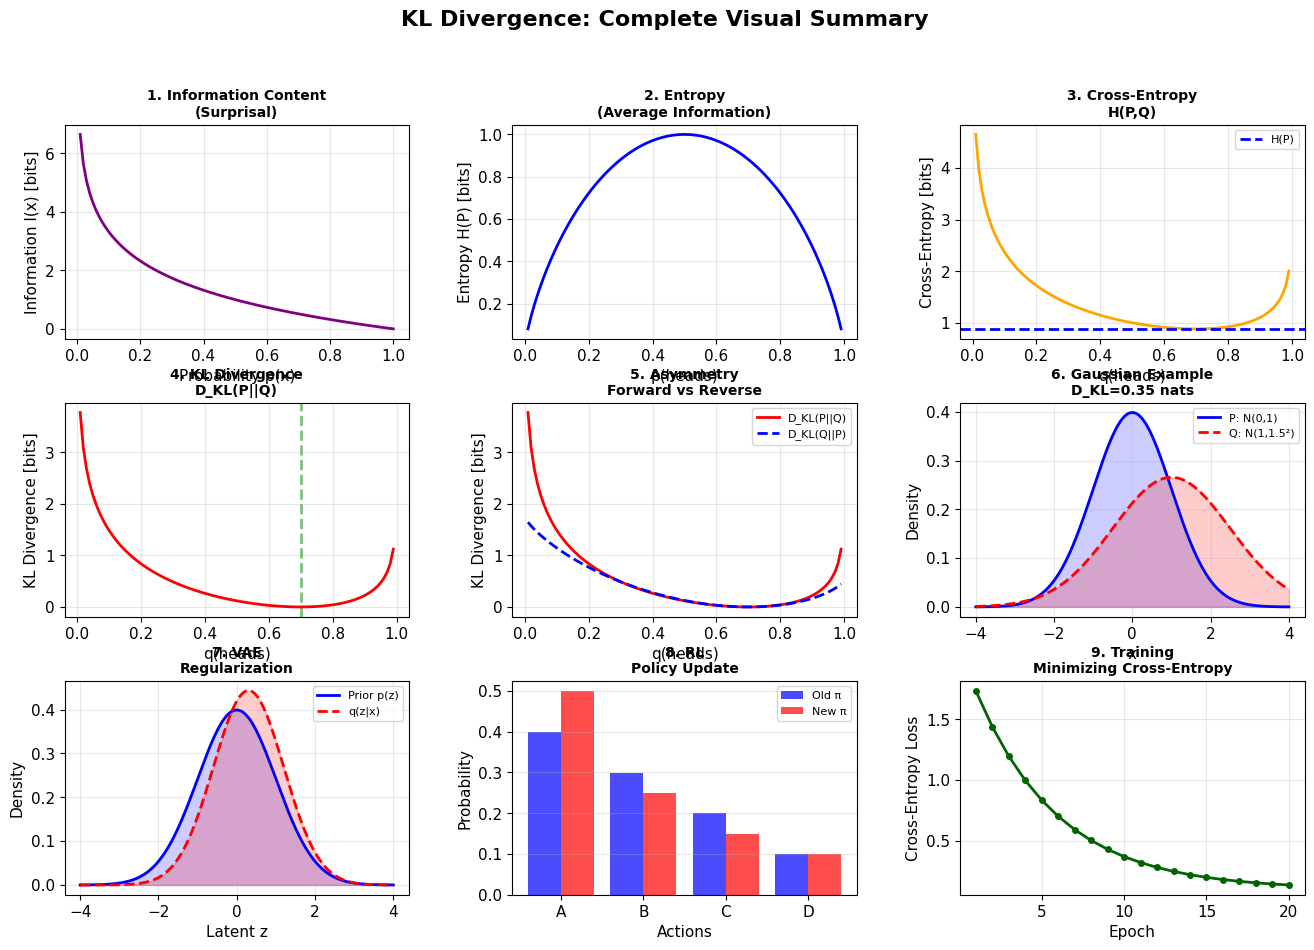


COMPLETE! You now understand KL divergence from the ground up.


In [23]:
# Create a comprehensive summary visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Information content
ax1 = fig.add_subplot(gs[0, 0])
probs = np.linspace(0.01, 1.0, 100)
info = -np.log2(probs)
ax1.plot(probs, info, linewidth=2, color='purple')
ax1.set_xlabel('Probability p(x)')
ax1.set_ylabel('Information I(x) [bits]')
ax1.set_title('1. Information Content\n(Surprisal)', fontsize=10, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Entropy
ax2 = fig.add_subplot(gs[0, 1])
p_vals = np.linspace(0.01, 0.99, 100)
entropies = [-p*np.log2(p) - (1-p)*np.log2(1-p) for p in p_vals]
ax2.plot(p_vals, entropies, linewidth=2, color='blue')
ax2.set_xlabel('p(heads)')
ax2.set_ylabel('Entropy H(P) [bits]')
ax2.set_title('2. Entropy\n(Average Information)', fontsize=10, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Cross-entropy
ax3 = fig.add_subplot(gs[0, 2])
p_true = np.array([0.7, 0.3])
q_heads_vals = np.linspace(0.01, 0.99, 100)
ce_vals = [cross_entropy(p_true, np.array([q, 1-q])) for q in q_heads_vals]
ax3.plot(q_heads_vals, ce_vals, linewidth=2, color='orange')
ax3.axhline(entropy(p_true), linestyle='--', color='blue', label='H(P)')
ax3.set_xlabel('q(heads)')
ax3.set_ylabel('Cross-Entropy [bits]')
ax3.set_title('3. Cross-Entropy\nH(P,Q)', fontsize=10, fontweight='bold')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# 4. KL divergence (1D)
ax4 = fig.add_subplot(gs[1, 0])
kl_vals = [kl_divergence(p_true, np.array([q, 1-q])) for q in q_heads_vals]
ax4.plot(q_heads_vals, kl_vals, linewidth=2, color='red')
ax4.axvline(0.7, linestyle='--', color='green', alpha=0.5)
ax4.set_xlabel('q(heads)')
ax4.set_ylabel('KL Divergence [bits]')
ax4.set_title('4. KL Divergence\nD_KL(P||Q)', fontsize=10, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. Asymmetry
ax5 = fig.add_subplot(gs[1, 1])
kl_pq = [kl_divergence(p_true, np.array([q, 1-q])) for q in q_heads_vals]
kl_qp = [kl_divergence(np.array([q, 1-q]), p_true) for q in q_heads_vals]
ax5.plot(q_heads_vals, kl_pq, linewidth=2, label='D_KL(P||Q)', color='red')
ax5.plot(q_heads_vals, kl_qp, linewidth=2, label='D_KL(Q||P)', color='blue', linestyle='--')
ax5.set_xlabel('q(heads)')
ax5.set_ylabel('KL Divergence [bits]')
ax5.set_title('5. Asymmetry\nForward vs Reverse', fontsize=10, fontweight='bold')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# 6. Gaussian KL
ax6 = fig.add_subplot(gs[1, 2])
x = np.linspace(-4, 4, 1000)
p_gauss = stats.norm.pdf(x, 0, 1)
q_gauss = stats.norm.pdf(x, 1, 1.5)
ax6.plot(x, p_gauss, linewidth=2, label='P: N(0,1)', color='blue')
ax6.plot(x, q_gauss, linewidth=2, label='Q: N(1,1.5²)', color='red', linestyle='--')
ax6.fill_between(x, p_gauss, alpha=0.2, color='blue')
ax6.fill_between(x, q_gauss, alpha=0.2, color='red')
ax6.set_xlabel('x')
ax6.set_ylabel('Density')
ax6.set_title(f'6. Gaussian Example\nD_KL={kl_gaussian(0,1,1,1.5):.2f} nats', fontsize=10, fontweight='bold')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

# 7. VAE application
ax7 = fig.add_subplot(gs[2, 0])
prior = stats.norm.pdf(x, 0, 1)
posterior = stats.norm.pdf(x, 0.3, 0.9)
ax7.plot(x, prior, linewidth=2, label='Prior p(z)', color='blue')
ax7.plot(x, posterior, linewidth=2, label='q(z|x)', color='red', linestyle='--')
ax7.fill_between(x, prior, alpha=0.2, color='blue')
ax7.fill_between(x, posterior, alpha=0.2, color='red')
ax7.set_xlabel('Latent z')
ax7.set_ylabel('Density')
ax7.set_title('7. VAE\nRegularization', fontsize=10, fontweight='bold')
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.3)

# 8. RL application
ax8 = fig.add_subplot(gs[2, 1])
actions = ['A', 'B', 'C', 'D']
old_policy = [0.4, 0.3, 0.2, 0.1]
new_policy = [0.5, 0.25, 0.15, 0.1]
x_pos = np.arange(len(actions))
ax8.bar(x_pos - 0.2, old_policy, 0.4, label='Old π', color='blue', alpha=0.7)
ax8.bar(x_pos + 0.2, new_policy, 0.4, label='New π', color='red', alpha=0.7)
ax8.set_xlabel('Actions')
ax8.set_ylabel('Probability')
ax8.set_title('8. RL\nPolicy Update', fontsize=10, fontweight='bold')
ax8.set_xticks(x_pos)
ax8.set_xticklabels(actions)
ax8.legend(fontsize=8)
ax8.grid(True, alpha=0.3, axis='y')

# 9. Training loss
ax9 = fig.add_subplot(gs[2, 2])
epochs_viz = np.arange(1, 21)
loss_curve = 2.0 * np.exp(-epochs_viz / 5) + 0.1
ax9.plot(epochs_viz, loss_curve, linewidth=2, marker='o', markersize=4, color='darkgreen')
ax9.set_xlabel('Epoch')
ax9.set_ylabel('Cross-Entropy Loss')
ax9.set_title('9. Training\nMinimizing Cross-Entropy', fontsize=10, fontweight='bold')
ax9.grid(True, alpha=0.3)

fig.suptitle('KL Divergence: Complete Visual Summary', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('kl_divergence_summary.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("COMPLETE! You now understand KL divergence from the ground up.")
print("="*70)

### Final Thoughts

**KL divergence is fundamental to modern machine learning**. You've now built the intuition to:

1. ✓ Understand why it measures "difference" between distributions
2. ✓ See how it emerges naturally from information theory
3. ✓ Recognize it in VAEs, RL, classification, and more
4. ✓ Know when to use $D_{KL}(P \| Q)$ vs $D_{KL}(Q \| P)$
5. ✓ Visualize and compute it for both discrete and continuous distributions

**Next steps**:
- Explore other divergences: Jensen-Shannon, Wasserstein distance
- Implement VAE and see KL regularization in action
- Study TRPO/PPO to see KL constraints in RL
- Read about the information bottleneck principle

**Remember the core insight**: KL divergence is the extra cost (in bits or nats) of using the wrong probability distribution. Everything else follows from this simple but powerful idea.